# Data Cleaning


In [1]:
import sys
from pathlib import Path

# Add project root directory to sys.path
sys.path.append(str(Path.cwd().parent))

# Now import your custom modules
import pandas as pd
from plotnine import *
import numpy as np
import seaborn as sns
from scripts.profiling import *

#### Import the dataset

In [2]:
customers_raw = pd.read_csv('../data/raw/customers.csv')
sales_raw = pd.read_csv('../data/raw/sales.csv')
orders_raw = pd.read_csv('../data/raw/orders.csv')
experiment_raw = pd.read_csv('../data/raw/experiment.csv')
vendors_raw = pd.read_csv('../data/raw/vendors.csv')
product_raw = pd.read_csv('../data/raw/product_usage.csv')

### Profiling

Table 1.1   
**CUSTOMERS**

In [3]:
display(customers_raw)

,customer_id,company_name,country,industry,employee_count,devices_managed,customer_start_date,customer_status,annual_revenue,acquisition_source,plan
0,CUST-0001,Customer 001,United Kingdom,Technology,118,27,2025-04-25,Active,7130,Accelerator,Starter
1,CUST-0002,Customer 002,United States,FinTech,68,18,2026-07-13,Active,4750,Event,Starter
2,CUST-0003,Customer 003,France,E-commerce,71,30,2026-07-29,Active,7920,Event,Starter
3,CUST-0004,Customer 004,Canada,FinTech,473,89,2025-01-07,Active,19220,Inbound,Growth
4,CUST-0005,Customer 005,Nigeria,Healthcare,79,17,2025-12-11,Active,4490,Outbound,Starter
...,...,...,...,...,...,...,...,...,...,...,...
142,CUST-0143,Customer 143,Germany,Professional Services,32,11,2025-08-15,Active,2380,Accelerator,Growth
143,CUST-0144,Customer 144,Germany,FinTech,39,22,2025-05-24,Active,5810,Event,Starter
144,CUST-0145,Customer 145,France,Education,54,29,2026-04-10,Churned,6260,Accelerator,Growth
145,CUST-0018,Customer 018,US,Professional Services,135,40,2026-05-28,Active,8640,Accelerator,Growth



═════════════════════════════════════════════════════════════════
  AUTOMATED PROFILING REPORT
  Shape : 147 rows × 11 columns

═════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  1. STRUCTURE & DATA TYPES
─────────────────────────────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_id          147 non-null    str  
 1   company_name         147 non-null    str  
 2   country              145 non-null    str  
 3   industry             147 non-null    str  
 4   employee_count       147 non-null    int64
 5   devices_managed      147 non-null    int64
 6   customer_start_date  147 non-null    str  
 7   customer_status      147 non-null    str  
 8   annual_revenue       147 non-null    int64
 9   acquisition_sourc

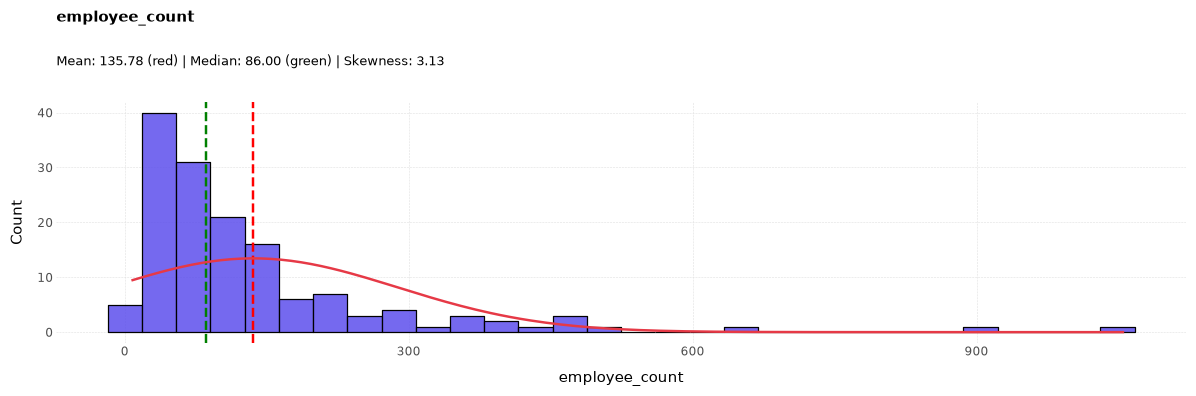

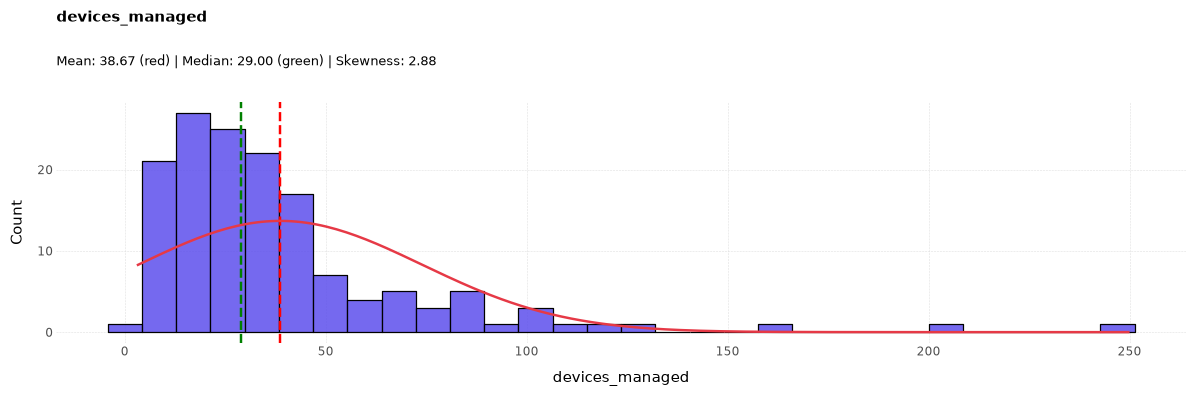

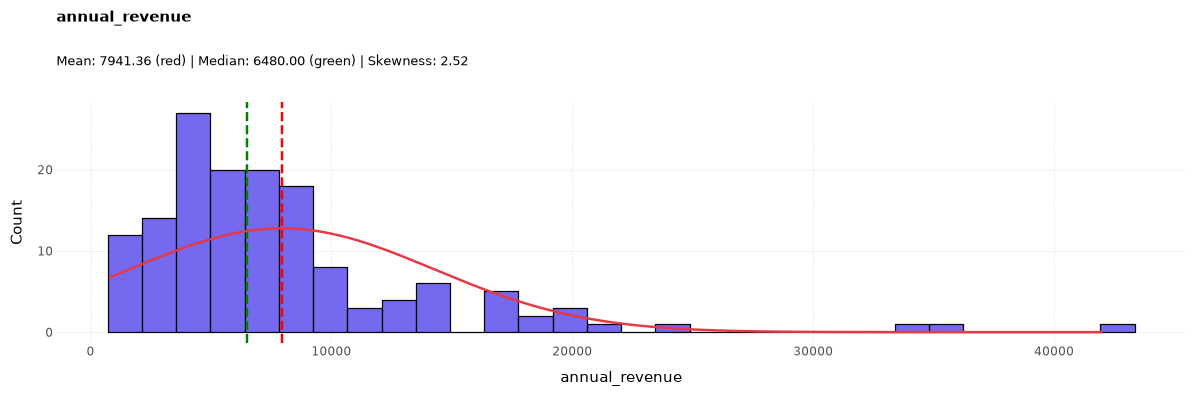


─────────────────────────────────────────────────────────────────
  7. OUTLIERS — IQR Method (numeric columns)
─────────────────────────────────────────────────────────────────

  Column                          Outliers       %  Fence
  ────────────────────────────────────────────────────────────
  employee_count                 ⚠      16   10.9%  [-102.0, 294.0]
  devices_managed                ⚠      14    9.5%  [-23.5, 84.5]
  annual_revenue                 ⚠      14    9.5%  [-3,570.0, 16,510.0]

─────────────────────────────────────────────────────────────────

  ⚠  3 column(s) have outliers.

  ▶  Review each flagged column — outliers are not automatically errors.

  ▶  Ask: is this an entry error, a legitimate extreme event, or the most interesting observation in the dataset?

  ▶  For modelling: consider whether to keep, cap (winsorise), or log-transform. Never remove without investigation.

─────────────────────────────────────────────────────────────────
  8. CATEGORICAL CO

In [4]:
profile(customers_raw)

Table 1.2   
**SALES**

In [5]:
sales_raw.head()

,lead_id,company_name,country,industry,lead_source,date_created,sales_stage,date_converted,contract_value,outcome,lost_reason
0,LEAD-00001,Prospect 0001,NaN,Technology,Outbound,2025-08-03,Qualified,NaN,32700.0,NaN,NaN
1,LEAD-00002,Prospect 0002,USA,E-commerce,Partner,2026-08-13,Lead,NaN,77600.0,NaN,NaN
2,LEAD-00003,Prospect 0003,United States,Technology,Event,2025-06-22,Closed Lost,2025-08-28,4600.0,Lost,Timing
3,LEAD-00004,Prospect 0004,Canada,FinTech,Referral,2025-12-13,Proposal,NaN,8600.0,NaN,NaN
4,LEAD-00005,Prospect 0005,Netherlands,FinTech,Accelerator,2025-05-02,Qualified,NaN,15900.0,NaN,NaN



═════════════════════════════════════════════════════════════════
  AUTOMATED PROFILING REPORT
  Shape : 430 rows × 11 columns

═════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  1. STRUCTURE & DATA TYPES
─────────────────────────────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 430 entries, 0 to 429
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   lead_id         430 non-null    str    
 1   company_name    430 non-null    str    
 2   country         420 non-null    str    
 3   industry        430 non-null    str    
 4   lead_source     430 non-null    str    
 5   date_created    430 non-null    str    
 6   sales_stage     430 non-null    str    
 7   date_converted  96 non-null     str    
 8   contract_value  430 non-null    float64
 9   outcome         96 non-null     str    
 10  lost_

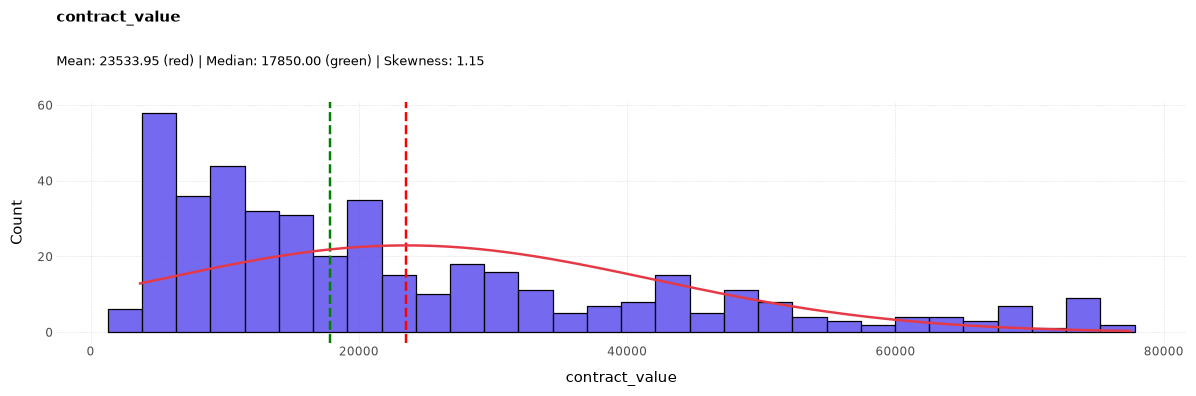


─────────────────────────────────────────────────────────────────
  7. OUTLIERS — IQR Method (numeric columns)
─────────────────────────────────────────────────────────────────

  Column                          Outliers       %  Fence
  ────────────────────────────────────────────────────────────
  contract_value                 ⚠      20    4.7%  [-25,225.0, 66,575.0]

─────────────────────────────────────────────────────────────────

  ⚠  1 column(s) have outliers.

  ▶  Review each flagged column — outliers are not automatically errors.

  ▶  Ask: is this an entry error, a legitimate extreme event, or the most interesting observation in the dataset?

  ▶  For modelling: consider whether to keep, cap (winsorise), or log-transform. Never remove without investigation.

─────────────────────────────────────────────────────────────────
  8. CATEGORICAL COLUMNS
─────────────────────────────────────────────────────────────────

  lead_id — 430 unique values
  Top 3: {'LEAD-00001': np.int

In [6]:
profile(sales_raw)

Table 1.3   
**ORDERS**

In [7]:
orders_raw.head()

,order_id,customer_id,device_type,device_model,quantity,order_date,delivery_date,order_status,country,order_value
0,ORD-00001,CUST-0107,Monitor,MacBook Air M3,10,2025-04-12,NaN,In Transit,UK,3720
1,ORD-00002,CUST-0093,Monitor,MacBook Air M3,2,2025-04-12,NaN,Failed,Nigeria,688
2,ORD-00003,CUST-0006,Desktop,Lenovo ThinkPad T14,2,2025-02-21,2025-03-03,Delivered,Canada,1140
3,ORD-00004,CUST-0060,Tablet,MacBook Air M3,20,2025-12-03,2025-12-05,Delivered,Netherlands,16060
4,ORD-00005,CUST-0045,Laptop,MacBook Pro M4,1,2025-04-23,2025-04-24,Delivered,UK,1137



═════════════════════════════════════════════════════════════════
  AUTOMATED PROFILING REPORT
  Shape : 720 rows × 10 columns

═════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  1. STRUCTURE & DATA TYPES
─────────────────────────────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   order_id       720 non-null    str  
 1   customer_id    720 non-null    str  
 2   device_type    720 non-null    str  
 3   device_model   720 non-null    str  
 4   quantity       720 non-null    int64
 5   order_date     720 non-null    str  
 6   delivery_date  615 non-null    str  
 7   order_status   720 non-null    str  
 8   country        710 non-null    str  
 9   order_value    720 non-null    int64
dtypes: int64(2), str(8)
memory usage: 56.4 KB

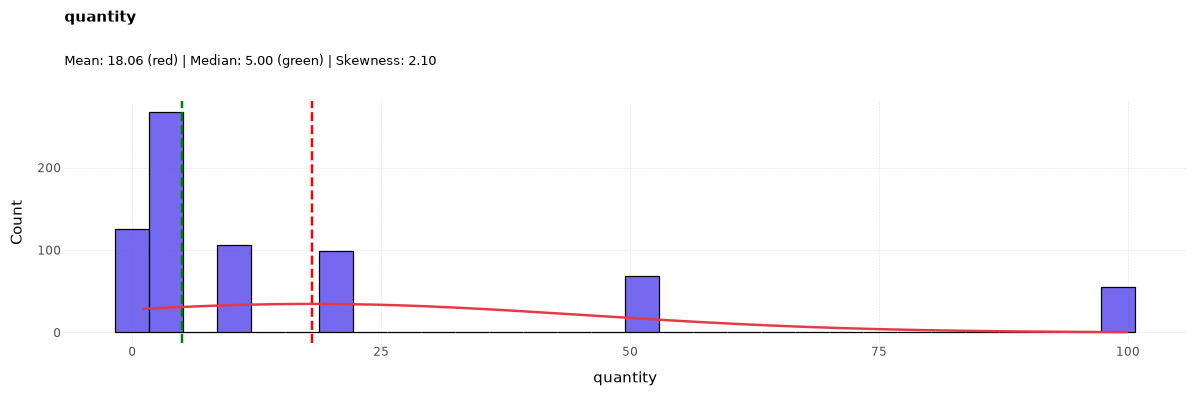

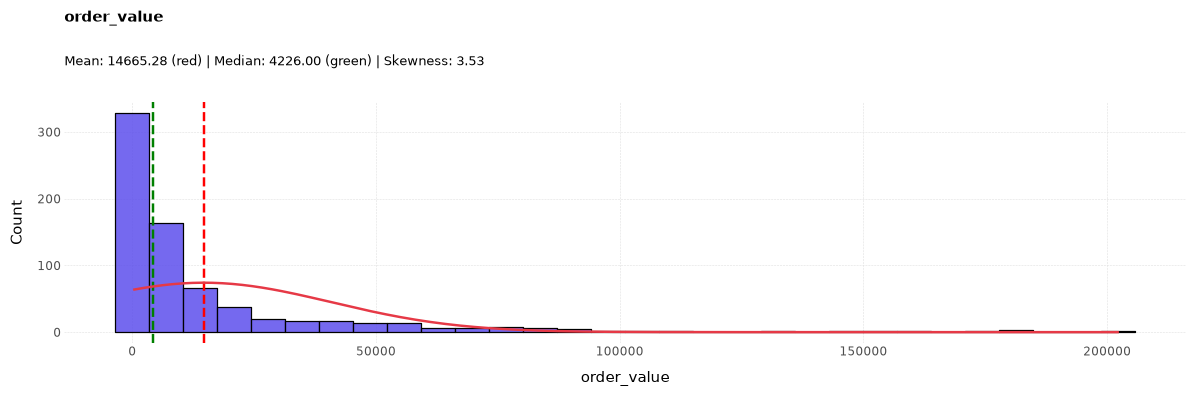


─────────────────────────────────────────────────────────────────
  7. OUTLIERS — IQR Method (numeric columns)
─────────────────────────────────────────────────────────────────

  Column                          Outliers       %  Fence
  ────────────────────────────────────────────────────────────
  quantity                       ⚠     123   17.1%  [-25.0, 47.0]
  order_value                    ⚠      98   13.6%  [-19,127.5, 35,392.5]

─────────────────────────────────────────────────────────────────

  ⚠  2 column(s) have outliers.

  ▶  Review each flagged column — outliers are not automatically errors.

  ▶  Ask: is this an entry error, a legitimate extreme event, or the most interesting observation in the dataset?

  ▶  For modelling: consider whether to keep, cap (winsorise), or log-transform. Never remove without investigation.

─────────────────────────────────────────────────────────────────
  8. CATEGORICAL COLUMNS
─────────────────────────────────────────────────────────────

In [8]:
profile(orders_raw)

Table 1.4     
**experiment**

In [9]:
experiment_raw.head()

,experiment_id,customer_id,group,baseline_weekly_actions,post_weekly_actions,target_feature_adopted
0,EXP-001,CUST-0119,Treatment,3,3,0
1,EXP-002,CUST-0138,Treatment,6,4,1
2,EXP-003,CUST-0019,Treatment,5,7,0
3,EXP-004,CUST-0036,Treatment,3,8,0
4,EXP-005,CUST-0077,Treatment,4,6,0



═════════════════════════════════════════════════════════════════
  AUTOMATED PROFILING REPORT
  Shape : 80 rows × 6 columns

═════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  1. STRUCTURE & DATA TYPES
─────────────────────────────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   experiment_id            80 non-null     str  
 1   customer_id              80 non-null     str  
 2   group                    80 non-null     str  
 3   baseline_weekly_actions  80 non-null     int64
 4   post_weekly_actions      80 non-null     int64
 5   target_feature_adopted   80 non-null     int64
dtypes: int64(3), str(3)
memory usage: 3.9 KB
None

─────────────────────────────────────────────────────────────────

  ✔  3 numeric colum

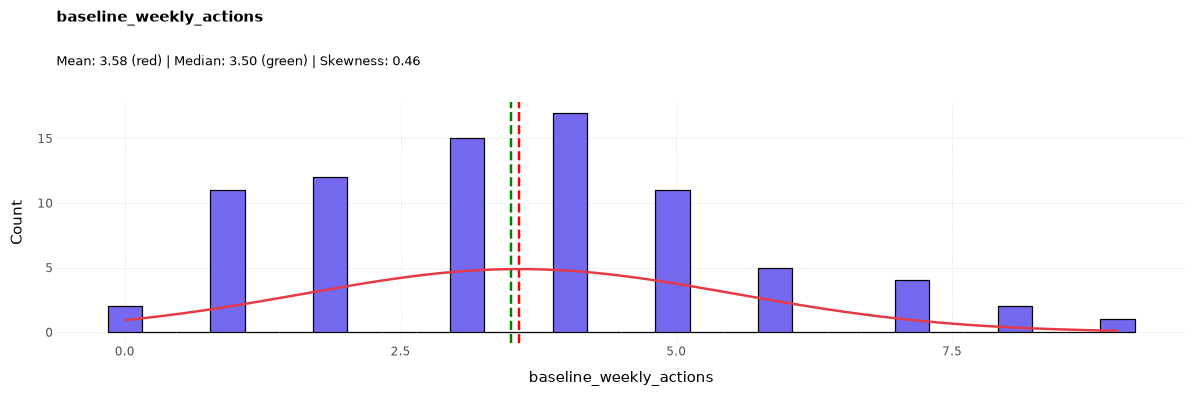

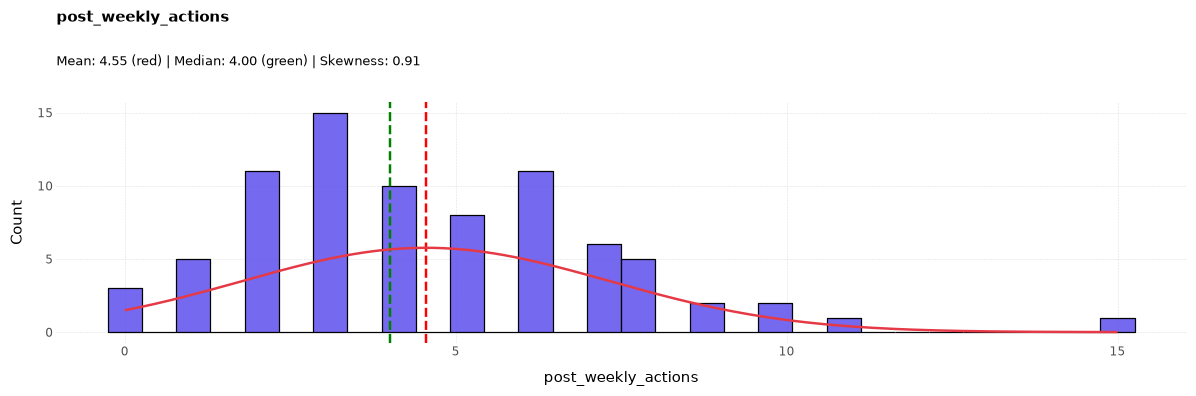


─────────────────────────────────────────────────────────────────
  7. OUTLIERS — IQR Method (numeric columns)
─────────────────────────────────────────────────────────────────

  Column                          Outliers       %  Fence
  ────────────────────────────────────────────────────────────
  baseline_weekly_actions                0    0.0%  [-2.5, 9.5]
  post_weekly_actions            ⚠       2    2.5%  [-1.5, 10.5]
  target_feature_adopted            binary       —  skipped

─────────────────────────────────────────────────────────────────

  ⚠  1 column(s) have outliers.

  ▶  Review each flagged column — outliers are not automatically errors.

  ▶  Ask: is this an entry error, a legitimate extreme event, or the most interesting observation in the dataset?

  ▶  For modelling: consider whether to keep, cap (winsorise), or log-transform. Never remove without investigation.

─────────────────────────────────────────────────────────────────
  8. CATEGORICAL COLUMNS
────────────

In [10]:
profile(experiment_raw)

Table 1.5   
**VENDORS**

In [11]:
vendors_raw.head()

,vendor_id,vendor_name,country,vendor_type,vendor_status,orders_fulfilled,avg_fulfilment_days,vendor_rating
0,VEND-001,Vendor 01,Netherlands,Repair,Preferred,47,1.4,3.4
1,VEND-002,Vendor 02,Singapore,Procurement & Storage,Preferred,104,8.7,4.2
2,VEND-003,Vendor 03,United Kingdom,Procurement & Storage,Temporary,48,5.9,4.1
3,VEND-004,Vendor 04,Netherlands,Procurement,Preferred,42,7.5,3.8
4,VEND-005,Vendor 05,US,Procurement,Temporary,89,4.2,4.2



═════════════════════════════════════════════════════════════════
  AUTOMATED PROFILING REPORT
  Shape : 54 rows × 8 columns

═════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  1. STRUCTURE & DATA TYPES
─────────────────────────────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vendor_id            54 non-null     str    
 1   vendor_name          54 non-null     str    
 2   country              54 non-null     str    
 3   vendor_type          54 non-null     str    
 4   vendor_status        54 non-null     str    
 5   orders_fulfilled     54 non-null     int64  
 6   avg_fulfilment_days  54 non-null     float64
 7   vendor_rating        54 non-null     float64
dtypes: float64(2), int64(1), str(5)
memory usage: 3.5 

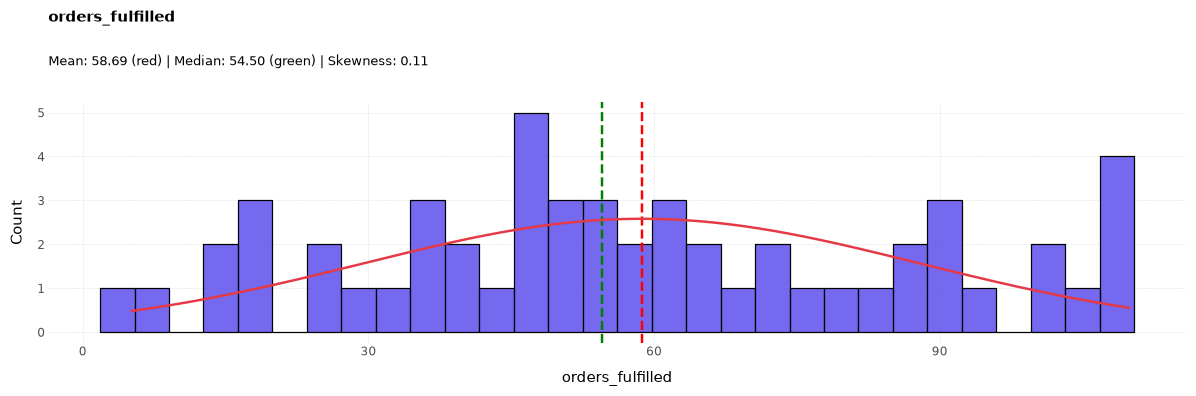

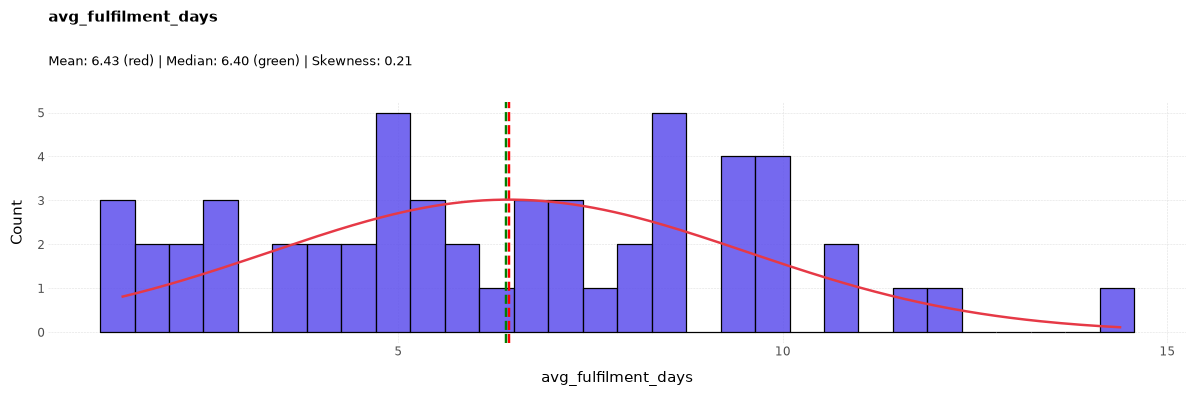

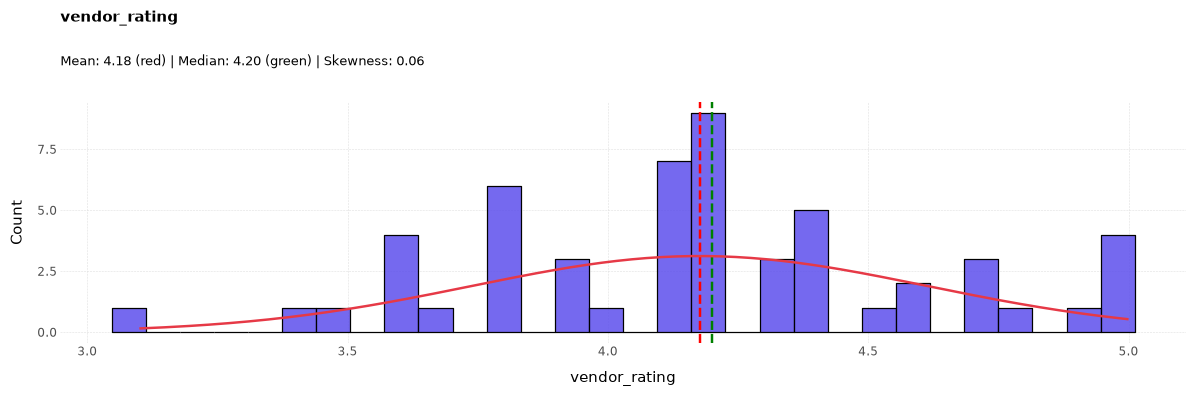


─────────────────────────────────────────────────────────────────
  7. OUTLIERS — IQR Method (numeric columns)
─────────────────────────────────────────────────────────────────

  Column                          Outliers       %  Fence
  ────────────────────────────────────────────────────────────
  orders_fulfilled                       0    0.0%  [-29.8, 152.2]
  avg_fulfilment_days                    0    0.0%  [-2.4, 15.3]
  vendor_rating                          0    0.0%  [3.0, 5.3]

─────────────────────────────────────────────────────────────────

  ✔  No outliers detected in any numeric column.

─────────────────────────────────────────────────────────────────
  8. CATEGORICAL COLUMNS
─────────────────────────────────────────────────────────────────

  vendor_id — 54 unique values
  Top 3: {'VEND-001': np.int64(1), 'VEND-002': np.int64(1), 'VEND-003': np.int64(1)}

  ⚠  'vendor_id' has 54 unique values — likely a free-text or ID column. Avoid using as a categorical feature.



In [12]:
profile(vendors_raw)

Table 1.6   
**PRODUCT USAGE**

In [13]:
product_raw.head()

,usage_id,customer_id,usage_date,feature,active_users,devices_in_scope
0,USG-000001,CUST-0123,2026-05-25,Device Fleet,40,43
1,USG-000002,CUST-0037,2026-07-27,Vendor Management,11,13
2,USG-000003,CUST-0144,2026-02-13,Orders,63,76
3,USG-000004,CUST-0064,2026-01-22,Orders,52,79
4,USG-000005,CUST-0122,2026-05-14,Vendor Management,73,98



═════════════════════════════════════════════════════════════════
  AUTOMATED PROFILING REPORT
  Shape : 2,500 rows × 6 columns

═════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  1. STRUCTURE & DATA TYPES
─────────────────────────────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   usage_id          2500 non-null   str  
 1   customer_id       2500 non-null   str  
 2   usage_date        2500 non-null   str  
 3   feature           2500 non-null   str  
 4   active_users      2500 non-null   int64
 5   devices_in_scope  2500 non-null   int64
dtypes: int64(2), str(4)
memory usage: 117.3 KB
None

─────────────────────────────────────────────────────────────────

  ✔  2 numeric column(s): ['active_users', 'devices_in_scope']

  ✔

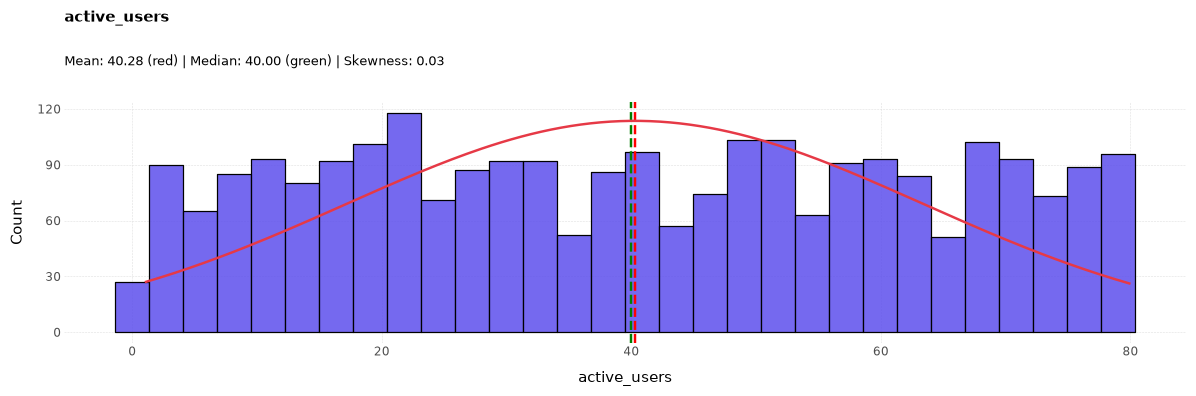

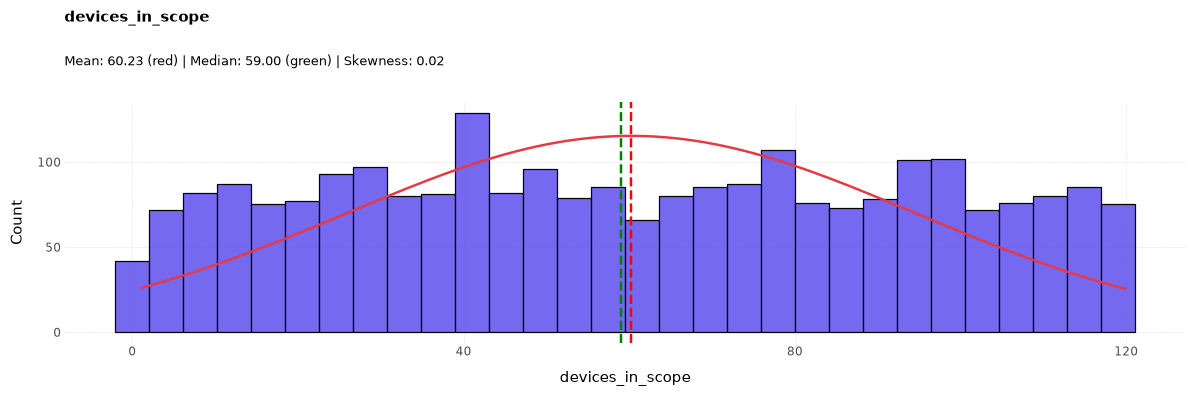


─────────────────────────────────────────────────────────────────
  7. OUTLIERS — IQR Method (numeric columns)
─────────────────────────────────────────────────────────────────

  Column                          Outliers       %  Fence
  ────────────────────────────────────────────────────────────
  active_users                           0    0.0%  [-40.0, 120.0]
  devices_in_scope                       0    0.0%  [-59.6, 181.4]

─────────────────────────────────────────────────────────────────

  ✔  No outliers detected in any numeric column.

─────────────────────────────────────────────────────────────────
  8. CATEGORICAL COLUMNS
─────────────────────────────────────────────────────────────────

  usage_id — 2500 unique values
  Top 3: {'USG-000001': np.int64(1), 'USG-000002': np.int64(1), 'USG-000003': np.int64(1)}

  ⚠  'usage_id' has 2500 unique values — likely a free-text or ID column. Avoid using as a categorical feature.

  customer_id — 146 unique values
  Top 3: {'CUST-999

In [14]:
profile(product_raw)

In [15]:
#!pip freeze > requirements.txt